In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit import transpile
from qiskit.circuit import ParameterVector, ClassicalRegister
from qiskit_aer import QasmSimulator
from PTC_utils import PTC_pairs, qaoa_PTC, decode_parity
from SWAP_utils import SWAP_pairs, qaoa_SWAP, qubit_order
from utils import total_cnots_depth, cost_maxcut, WMaxCut, qaoa, objective_MaxCut, random_samples, mitigate
from copy import copy
from simulated_annealing import simulated_annealing_func
import networkx as nx
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
import os
service = QiskitRuntimeService()


In [2]:
backends = {}
backends["ibm_kingston"] = service.backend("ibm_kingston", use_fractional_gates=False)
backends["qasm_simulator"] = QasmSimulator()
backends["qiskit_mps"] = AerSimulator(method='matrix_product_state', matrix_product_state_max_bond_dimension=4)


In [3]:
def method_SA(G, method, callback, max_iter_sa = 5, initial_temp=0.01, cooling_rate=0.999, stop_temp=1e-8, max_iter=10000, verbose=False):
    nq = G.number_of_nodes()
    if method == "PTC":
        list_2q = PTC_pairs(nq)
    elif method == "SWAP":
        list_2q = SWAP_pairs(nq)
    else:
        raise TypeError("Method not in list of methods")
    best_cost = 0
    global_best = dict(zip(range(nq), range(nq)))
    best_map = dict(zip(range(nq), range(nq)))
    for i in range(max_iter_sa):
        best_map, current_cost, _ = simulated_annealing_func(G, best_map, list_2q, callback, initial_temp=initial_temp, cooling_rate=cooling_rate, stop_temp=stop_temp, max_iter=max_iter, verbose=verbose)
        if current_cost < best_cost:
            best_cost = current_cost
            global_best = copy(best_map)
        else:
            break
    mapping = {v: k for k, v in global_best.items()}
    G_shuffled = nx.relabel_nodes(G.copy(), mapping)
    _ , depth = total_cnots_depth(G_shuffled, list_2q)
    list_used = copy(list_2q[:nq+depth])
    return mapping, list_used

In [35]:
results = {}
seed = 1
results["seed"] = seed
method = ["SWAP","PTC","Qiskit-T"][0]
# backend_name = "qasm_simulator"
backend_name = "ibm_kingston"

# G = nx.random_regular_graph(3, nq, seed=results["seed"])
graphs = np.load(f"./Data/problems_transpilers_{seed}.npy", allow_pickle=True).item()

seed = 1
nq = 100
if nq in graphs.keys():
    probs = graphs["probs"]
    Ed = probs[nq][0]
    problem_name = f"MC_Ed{Ed}"

    print(f"nq: {nq}, Ed: {Ed}")
    G = graphs["G"][nq][Ed]
    for i, j in G.edges():
        G[i][j]["weight"] = 1
else:
    Ed = 0.2
    G = nx.erdos_renyi_graph(nq, Ed, seed=seed)
backend = backends[backend_name]

deltas = [0.5]

results["Deltas"]  = deltas
if method in ["SWAP", "PTC"]:
    callback = {"cost": [], "depth": [], "iterations": [], "T": [], "cost_cache": {}}
    mapping, list_used = method_SA(G, method, callback, initial_temp=0.01, cooling_rate=0.99999, max_iter_sa=1,max_iter=1e6, verbose=True)
    G_shuffled = nx.relabel_nodes(G.copy(), mapping)
    results["G_shuffled"] = G_shuffled
    results["mapping"] = mapping
    results["list_used"] = list_used

best depth:0 | best cost:-43 | iteration:3 | T:0.0100
best depth:0 | best cost:-45 | iteration:5 | T:0.0100
best depth:0 | best cost:-46 | iteration:6 | T:0.0100
best depth:0 | best cost:-47 | iteration:32 | T:0.0100
best depth:0 | best cost:-48 | iteration:50 | T:0.0100
best depth:-1 | best cost:-89 | iteration:145 | T:0.0100
best depth:-1 | best cost:-90 | iteration:163 | T:0.0100
best depth:-1 | best cost:-91 | iteration:170 | T:0.0100
best depth:-1 | best cost:-92 | iteration:185 | T:0.0100
best depth:-1 | best cost:-93 | iteration:187 | T:0.0100
best depth:-1 | best cost:-94 | iteration:206 | T:0.0100
best depth:-1 | best cost:-95 | iteration:210 | T:0.0100
best depth:-1 | best cost:-96 | iteration:211 | T:0.0100
best depth:-1 | best cost:-97 | iteration:270 | T:0.0100
best depth:-1 | best cost:-98 | iteration:271 | T:0.0100
best depth:-2 | best cost:-133 | iteration:304 | T:0.0100
best depth:-2 | best cost:-134 | iteration:307 | T:0.0100
best depth:-2 | best cost:-135 | iteration

In [9]:
ps = [10]
results["ps"] = ps
# results["optimal"] = sol
results["G"] = G
results["circuits"] = {}
results["depth"] = {}
circuits_transpiled = {}
for p in ps:
    betas = ParameterVector("betas", p)
    gammas = ParameterVector("gammas", p)
    if method == "PTC":
        qc = qaoa_PTC(gammas, betas, G_shuffled, list_used)
        print("Depth reduction", nq - len(list_used))
    elif method == "SWAP":
        qc = qaoa_SWAP(gammas, betas, G_shuffled, list_used)
        print("Depth reduction", nq - len(list_used))
    elif method == "Qiskit-T":
        qc = qaoa(gammas, betas, G)
    qc.add_register(ClassicalRegister(nq))
    qc.measure(reversed(range(nq)), range(nq))
    circ_device = transpile(qc, backend, optimization_level=2)
    # circ_device = qc
    circuits_transpiled[p] = circ_device
    results["circuits"][p] = circ_device.count_ops()
    results["depth"][p] = circ_device.depth()
    print(circ_device.count_ops(), "depth: ", circ_device.depth())
circuits = []
for delta in deltas:
    print(f"Delta: -------  {round(delta,2)} ----------- ")
    for p in ps:
        betas = list(np.arange(1, p+1)[::-1] * delta / p)
        gammas = list(np.arange(1, p+1) * delta / p)
        backend_circ = circuits_transpiled[p].assign_parameters(np.concatenate((betas, gammas)))
        circuits.append(backend_circ)

Depth reduction 51
OrderedDict([('sx', 135792), ('rz', 79015), ('cz', 70200), ('measure', 100), ('x', 89)]) depth:  4346
Delta: -------  0.5 ----------- 


In [ ]:
from qiskit.transpiler.passes.routing.commuting_2q_gate_routing import SwapStrategy
from qopt_best_practices.sat_mapping import SATMapper
from qaoa_training_pipeline.utils.graph_utils import graph_to_operator
from qiskit.circuit.library import qaoa_ansatz
import time

graph = G.copy()
swap_strategy = SwapStrategy.from_line(range(graph.order()))
ti = time.time()
sat_graph, _, layers = SATMapper(timeout=2).remap_graph_with_sat(graph=graph, swap_strategy=swap_strategy)
tf = time.time() - ti
print(f"SAT mapping time: {tf:.2f} seconds")


SAT mapping time: 32.86 seconds
OrderedDict([('sx', 14767), ('cz', 7416), ('rz', 1432)]) depth:  2976


In [11]:
cost_op_sat = graph_to_operator(sat_graph, pre_factor=-0.5)
circuit_sat = qaoa_ansatz(cost_op_sat, reps=10)
# circ_device_sat = transpile(circuit_sat, backend, optimization_level=1)
circ_device_sat = transpile(circuit_sat, coupling_map=[[i,i+1] for i in range(nq-1)], basis_gates=["sx","rz","cz"], optimization_level=2)

print(circ_device_sat.count_ops(), "depth: ", circ_device_sat.depth())

OrderedDict([('sx', 202576), ('cz', 101628), ('rz', 12876)]) depth:  33777


In [ ]:
import time

seed = 1
nq = 100
p = 10
graphs = np.load(f"./Data/problems_transpilers_{seed}.npy", allow_pickle=True).item()
probs = graphs["probs"]
eds = [probs[nq][i] for i in range(3)]

backend = backends[backend_name]
coupling_map_1d = [[i, i+1] for i in range(nq-1)] + [[i+1, i] for i in range(nq-1)]
basis_gates = ["sx", "rz", "cz"]

sa_results = {"Ed": [], "time": [], "total_ops": [], "depth": [], "2q_gates": []}
sat_results = {"Ed": [], "time": [], "total_ops": [], "depth": [], "2q_gates": []}

for Ed_i in eds:
    print(f"\n{'='*50}")
    print(f"Ed = {Ed_i}")
    print(f"{'='*50}")

    G_ed = graphs["G"][nq][Ed_i]
    for i, j in G_ed.edges():
        G_ed[i][j]["weight"] = 1

    # --- SA method ---
    callback_sa = {"cost": [], "depth": [], "iterations": [], "T": [], "cost_cache": {}}
    ti = time.time()
    mapping_sa, list_used_sa = method_SA(
        G_ed, method, callback_sa,
        initial_temp=0.01, cooling_rate=0.9999, max_iter_sa=1, max_iter=1e6, verbose=False
    )
    sa_time = time.time() - ti

    G_shuffled_sa = nx.relabel_nodes(G_ed.copy(), mapping_sa)
    betas_pv = ParameterVector("betas", p)
    gammas_pv = ParameterVector("gammas", p)
    if method == "SWAP":
        qc_sa = qaoa_SWAP(gammas_pv, betas_pv, G_shuffled_sa, list_used_sa)
    elif method == "PTC":
        qc_sa = qaoa_PTC(gammas_pv, betas_pv, G_shuffled_sa, list_used_sa)
    qc_sa.add_register(ClassicalRegister(nq))
    qc_sa.measure(reversed(range(nq)), range(nq))
    circ_sa = transpile(qc_sa, coupling_map=coupling_map_1d, basis_gates=basis_gates, optimization_level=2)

    sa_ops = circ_sa.count_ops()
    sa_depth_val = circ_sa.depth()
    skip_gates = {"measure", "barrier"}
    sa_total = sum(v for k, v in sa_ops.items() if k not in skip_gates)
    sa_2q = sum(v for k, v in sa_ops.items() if k in ["cx", "cz", "ecr", "rzz"])

    sa_results["Ed"].append(Ed_i)
    sa_results["time"].append(sa_time)
    sa_results["total_ops"].append(sa_total)
    sa_results["depth"].append(sa_depth_val)
    sa_results["2q_gates"].append(sa_2q)

    print(f"  SA:  time={sa_time:.2f}s | total_ops={sa_total} | 2q_gates={sa_2q} | depth={sa_depth_val}")

    # --- SAT method ---
    graph_sat = G_ed.copy()
    swap_strategy_sat = SwapStrategy.from_line(range(graph_sat.order()))
    ti = time.time()
    sat_graph_ed, _, layers_sat = SATMapper(timeout=2).remap_graph_with_sat(
        graph=graph_sat, swap_strategy=swap_strategy_sat
    )
    sat_time = time.time() - ti

    cost_op = graph_to_operator(sat_graph_ed, pre_factor=-0.5)
    circuit_sat_ed = qaoa_ansatz(cost_op, reps=p)
    circ_sat = transpile(circuit_sat_ed, coupling_map=coupling_map_1d, basis_gates=basis_gates, optimization_level=2)

    sat_ops = circ_sat.count_ops()
    sat_depth_val = circ_sat.depth()
    sat_total = sum(v for k, v in sat_ops.items() if k not in skip_gates)
    sat_2q = sum(v for k, v in sat_ops.items() if k in ["cx", "cz", "ecr", "rzz"])

    sat_results["Ed"].append(Ed_i)
    sat_results["time"].append(sat_time)
    sat_results["total_ops"].append(sat_total)
    sat_results["depth"].append(sat_depth_val)
    sat_results["2q_gates"].append(sat_2q)

    print(f"  SAT: time={sat_time:.2f}s | total_ops={sat_total} | 2q_gates={sat_2q} | depth={sat_depth_val}")

print("\nComparison done!")


Ed = 0.04
  SA:  time=2.66s | total_ops=315440 | 2q_gates=77440 | depth=4702
  SAT: time=25.28s | total_ops=321058 | 2q_gates=102855 | depth=36722

Ed = 0.147
  SA:  time=2.76s | total_ops=514239 | 2q_gates=124960 | depth=7764


KeyboardInterrupt: 

In [15]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
import networkx as nx
from collections import defaultdict
import math 
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['font.size'] = 12
mpl.rcParams['figure.autolayout'] = False
mpl.rcParams['axes.linewidth'] = 1
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['lines.linewidth'] = 2.2
mpl.rcParams['lines.markersize'] = 5
mpl.rcParams['lines.markeredgewidth'] = 1.2
mpl.rcParams['errorbar.capsize'] = 5
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.major.size'] = 8
mpl.rcParams['xtick.minor.width'] = 1.5
mpl.rcParams['xtick.minor.size'] = 6
mpl.rcParams['ytick.minor.width'] = 1.5
mpl.rcParams['ytick.minor.size'] = 6
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['mathtext.fontset'] = 'dejavusans'
mpl.rcParams['font.family'] = 'sans-serif'
cm_colors = plt.get_cmap('Set2')


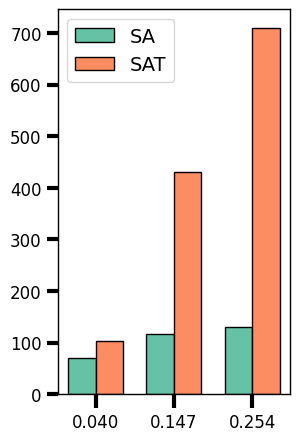

In [27]:
fig, ax = plt.subplots(figsize=(3,5))

ed_labels = [f"{e:.3f}" for e in sa_results["Ed"]]
x = np.arange(len(ed_labels))
width = 0.35

colors= plt.get_cmap('Set2')

# --- Total Operations ---
ax.bar(x - width/2, [i/1000 for i in sa_results["2q_gates"]], width, label="SA", color=colors(0), edgecolor='black')
ax.bar(x + width/2, [i/1000 for i in sat_results["2q_gates"]], width, label="SAT", color=colors(1), edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(ed_labels)
ax.legend()
fig.savefig(f"Figures/SA_vs_SAT_{method}_{backend_name}_{problem_name}_2q_gates.pdf", transparent=True, bbox_inches='tight')

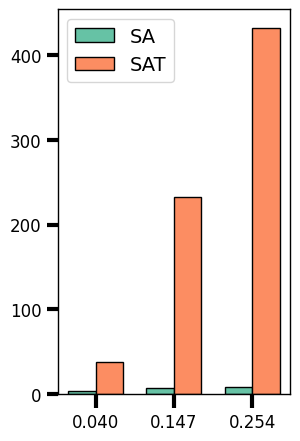

In [26]:
fig, ax = plt.subplots(figsize=(3,5))

ed_labels = [f"{e:.3f}" for e in sa_results["Ed"]]
x = np.arange(len(ed_labels))
width = 0.35

colors= plt.get_cmap('Set2')

# --- Total Operations ---
ax.bar(x - width/2, [i/1000 for i in sa_results["depth"]], width, label="SA", color=colors(0), edgecolor='black')
ax.bar(x + width/2, [i/1000 for i in sat_results["depth"]], width, label="SAT", color=colors(1), edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(ed_labels)
ax.legend()
fig.savefig(f"Figures/SA_vs_SAT_{method}_{backend_name}_{problem_name}_depth.pdf", transparent=True, bbox_inches='tight')

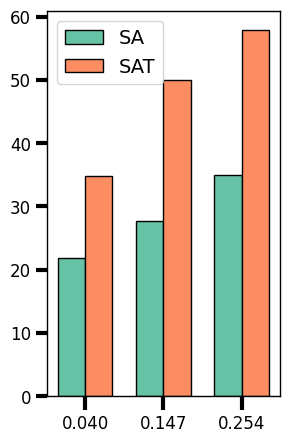

In [25]:
fig, ax = plt.subplots(figsize=(3,5))

ed_labels = [f"{e:.3f}" for e in sa_results["Ed"]]
x = np.arange(len(ed_labels))
width = 0.35

colors= plt.get_cmap('Set2')

# --- Total Operations ---
ax.bar(x - width/2, [i for i in sa_results["time"]], width, label="SA", color=colors(0), edgecolor='black')
ax.bar(x + width/2, [i for i in sat_results["time"]], width, label="SAT", color=colors(1), edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(ed_labels)
ax.legend()
fig.savefig(f"Figures/SA_vs_SAT_{method}_{backend_name}_{problem_name}.pdf", transparent=True, bbox_inches='tight')

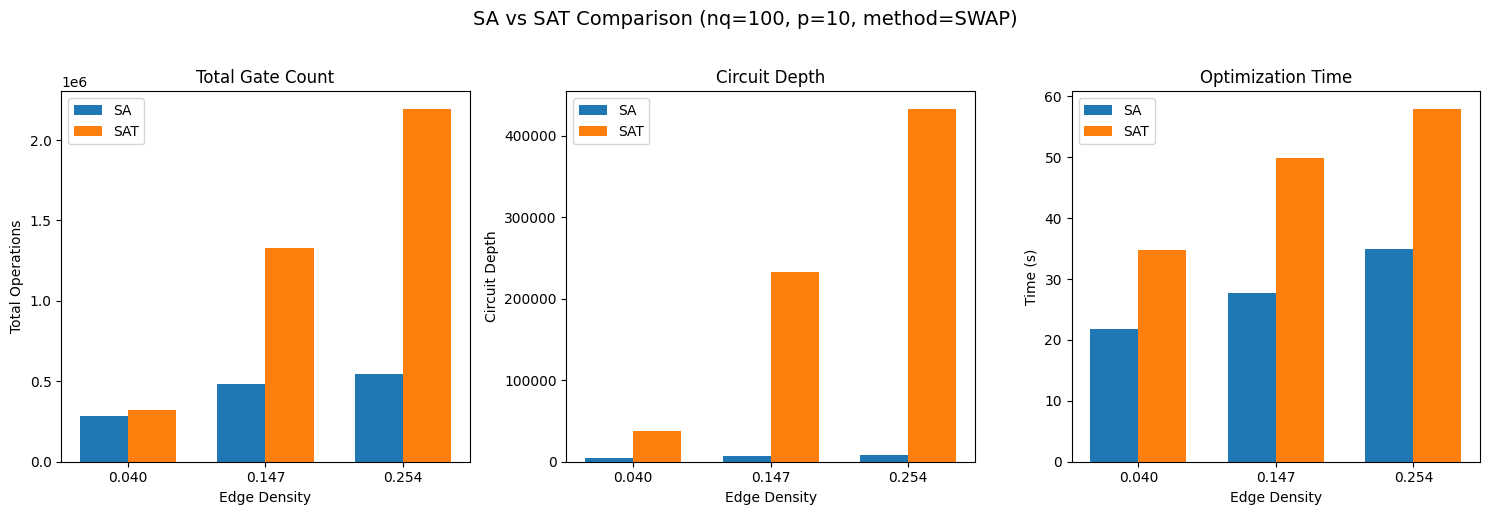

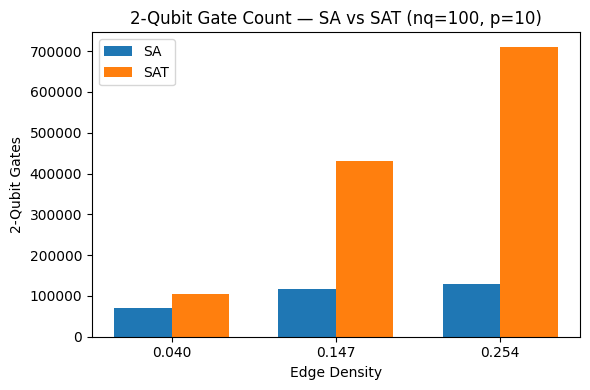

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ed_labels = [f"{e:.3f}" for e in sa_results["Ed"]]
x = np.arange(len(ed_labels))
width = 0.35

# --- Total Operations ---
ax = axes[0]
ax.bar(x - width/2, sa_results["total_ops"], width, label="SA", color="#1f77b4")
ax.bar(x + width/2, sat_results["total_ops"], width, label="SAT", color="#ff7f0e")
ax.set_xlabel("Edge Density")
ax.set_ylabel("Total Operations")
ax.set_title("Total Gate Count")
ax.set_xticks(x)
ax.set_xticklabels(ed_labels)
ax.legend()

# --- Circuit Depth ---
ax = axes[1]
ax.bar(x - width/2, sa_results["depth"], width, label="SA", color="#1f77b4")
ax.bar(x + width/2, sat_results["depth"], width, label="SAT", color="#ff7f0e")
ax.set_xlabel("Edge Density")
ax.set_ylabel("Circuit Depth")
ax.set_title("Circuit Depth")
ax.set_xticks(x)
ax.set_xticklabels(ed_labels)
ax.legend()

# --- Time ---
ax = axes[2]
ax.bar(x - width/2, sa_results["time"], width, label="SA", color="#1f77b4")
ax.bar(x + width/2, sat_results["time"], width, label="SAT", color="#ff7f0e")
ax.set_xlabel("Edge Density")
ax.set_ylabel("Time (s)")
ax.set_title("Optimization Time")
ax.set_xticks(x)
ax.set_xticklabels(ed_labels)
ax.legend()

fig.suptitle(f"SA vs SAT Comparison (nq={nq}, p={p}, method={method})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- 2-Qubit Gates ---
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.bar(x - width/2, sa_results["2q_gates"], width, label="SA", color="#1f77b4")
ax2.bar(x + width/2, sat_results["2q_gates"], width, label="SAT", color="#ff7f0e")
ax2.set_xlabel("Edge Density")
ax2.set_ylabel("2-Qubit Gates")
ax2.set_title(f"2-Qubit Gate Count — SA vs SAT (nq={nq}, p={p})")
ax2.set_xticks(x)
ax2.set_xticklabels(ed_labels)
ax2.legend()
plt.tight_layout()
plt.show()